In [2]:
# Cell 0: setup
from google.colab import drive; drive.mount('/content/drive')
!pip install -q lightgbm scikit-learn

import joblib, numpy as np, pandas as pd
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

model = joblib.load(f"{PROJECT}/models/model_canonical.joblib")
split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_test, y_test = split["X_test"], split["y_test"]
test_msno = split["test_msno"]

# Predicted churn probabilities on the test set (calibrated — this is why calibration mattered)
proba = model.predict_proba(X_test)[:, 1]
print("Test users:", len(X_test), "| mean predicted prob:", round(proba.mean(), 4),
      "| actual churn:", round(y_test.mean(), 4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test users: 96171 | mean predicted prob: 0.0621 | actual churn: 0.0622


In [3]:
# Cell 1: threshold sweep
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for t in np.arange(0.05, 0.95, 0.05):
    pred = (proba >= t).astype(int)
    if pred.sum() == 0:  # nobody flagged
        continue
    rows.append({
        "threshold": round(t, 2),
        "flagged": int(pred.sum()),
        "flagged_pct": round(100 * pred.mean(), 1),
        "precision": round(precision_score(y_test, pred), 3),
        "recall": round(recall_score(y_test, pred), 3),
        "f1": round(f1_score(y_test, pred), 3),
    })
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))

best_f1 = sweep.loc[sweep["f1"].idxmax()]
print(f"\nBest F1 at threshold {best_f1['threshold']}: "
      f"P={best_f1['precision']}, R={best_f1['recall']}, F1={best_f1['f1']}, "
      f"flags {best_f1['flagged_pct']}% of users")

 threshold  flagged  flagged_pct  precision  recall    f1
      0.05    12795         13.3      0.447   0.957 0.610
      0.10     9073          9.4      0.600   0.910 0.723
      0.15     6906          7.2      0.749   0.866 0.803
      0.20     6128          6.4      0.824   0.844 0.834
      0.25     5765          6.0      0.859   0.829 0.844
      0.30     5556          5.8      0.880   0.818 0.848
      0.35     5393          5.6      0.898   0.810 0.852
      0.40     5263          5.5      0.909   0.800 0.851
      0.45     5136          5.3      0.921   0.791 0.851
      0.50     5016          5.2      0.931   0.781 0.850
      0.55     4928          5.1      0.938   0.773 0.847
      0.60     4839          5.0      0.944   0.764 0.845
      0.65     4744          4.9      0.952   0.755 0.842
      0.70     4615          4.8      0.961   0.741 0.837
      0.75     4496          4.7      0.966   0.726 0.829
      0.80     4346          4.5      0.975   0.709 0.821
      0.85    

In [4]:
# Rejoin monthly_value from the feature matrix using test_msno
feat = pd.read_parquet(f"{PROJECT}/data/processed/features_v2.parquet")
val = feat.set_index("msno")["monthly_value"]
monthly_value = pd.Series(test_msno, name="msno").map(val).fillna(0).values

# Expected lifetime (months) from churn probability, capped to sane bounds.
# Interpretation: prob is over the prediction window; 1/prob approximates expected horizon.
exp_lifetime = np.clip(1.0 / np.clip(proba, 0.01, 1.0), 1, 60)  # 1 to 60 months
ltv_risk = monthly_value * exp_lifetime

biz = pd.DataFrame({
    "msno": test_msno,
    "churn_prob": proba,
    "actual_churn": y_test.values,
    "monthly_value": monthly_value,
    "exp_lifetime_months": exp_lifetime,
    "ltv_risk_adjusted": ltv_risk,
})
print(biz.describe().round(2).to_string())
print("\nSample (highest-risk users):")
print(biz.sort_values("churn_prob", ascending=False).head(5).to_string(index=False))

       churn_prob  actual_churn  monthly_value  exp_lifetime_months  ltv_risk_adjusted
count    96171.00      96171.00       96171.00             96171.00           96171.00
mean         0.06          0.06         129.02                52.10            6591.08
std          0.21          0.24          31.96                18.58            2707.19
min          0.00          0.00           0.00                 1.00               0.00
25%          0.00          0.00          99.00                60.00            5940.00
50%          0.00          0.00         149.00                60.00            5940.00
75%          0.01          0.00         149.00                60.00            8940.00
max          1.00          1.00        4470.00                60.00           10800.00

Sample (highest-risk users):
                                        msno  churn_prob  actual_churn  monthly_value  exp_lifetime_months  ltv_risk_adjusted
PNCVigUTy3Ey+6/kQoDNcGTqxW1qtBFdUM7Bbhy/6Gw=    0.999957     

In [5]:
# Cell: LTV
HORIZON = 24  # months a retained customer is expected to stay

biz = pd.DataFrame({
    "msno": test_msno,
    "churn_prob": proba,
    "actual_churn": y_test.values,
    "monthly_value": monthly_value,
})
biz["ltv"] = biz["monthly_value"] * HORIZON          # value if retained
biz["value_at_risk"] = biz["churn_prob"] * biz["ltv"]  # expected $ lost if we do nothing

print(biz[["churn_prob","monthly_value","ltv","value_at_risk"]].describe().round(2).to_string())
print("\nHighest value-at-risk customers:")
print(biz.sort_values("value_at_risk", ascending=False).head(5).to_string(index=False))

       churn_prob  monthly_value        ltv  value_at_risk
count    96171.00       96171.00   96171.00       96171.00
mean         0.06         129.02    3096.46         197.84
std          0.21          31.96     766.93         701.35
min          0.00           0.00       0.00           0.00
25%          0.00          99.00    2376.00           0.40
50%          0.00         149.00    3576.00           1.96
75%          0.01         149.00    3576.00          30.90
max          1.00        4470.00  107280.00       73697.48

Highest value-at-risk customers:
                                        msno  churn_prob  actual_churn  monthly_value      ltv  value_at_risk
NcZX/RK3ZC8tdatMRed2g5T21FoeahEOFp5zfyX2xl0=    0.686964             1         4470.0 107280.0   73697.475634
mxsczs85/AON6dvZwEanYxFR2G8NooS4gm5qXdPpb7s=    0.996091             1          180.0   4320.0    4303.113717
QlLPseVSEnyNHcWKHlV1Bi/K3JdQK0bRmOmnCldBmQM=    0.992558             1          180.0   4320.0    4287.84

In [6]:
# Cell: retention allocator — per-offer protects ~3 months (realistic)
MONTHS_PROTECTED = 3   # a successful retention offer keeps the customer ~1 quarter

def allocate(success_rate, offer_cost, budget=100_000.0):
    d = biz.copy()
    # $ saved per target = P(churn) × (months protected × monthly value) × P(offer works) − cost
    d["exp_gross"] = d["churn_prob"] * d["monthly_value"] * MONTHS_PROTECTED * success_rate
    d["exp_savings"] = d["exp_gross"] - offer_cost
    cand = d[d["exp_savings"] > 0].sort_values("exp_savings", ascending=False)
    n_afford = int(budget // offer_cost)
    targeted = cand.head(n_afford)
    spend = len(targeted) * offer_cost
    gross = targeted["exp_gross"].sum()
    net = gross - spend
    return {"success_rate": success_rate, "offer_cost": offer_cost,
            "n_worth": len(cand), "targeted": len(targeted),
            "spend": round(spend), "gross_saved": round(gross),
            "net_benefit": round(net),
            "return_pct": round(100*net/spend,1) if spend else None}

base = allocate(0.30, 30)
print("=== Base case (30% success, NT$30 offer, ~3 months protected) ===")
for k, v in base.items():
    print(f"  {k}: {v}")

# Model vs random — the robust headline
sr, oc = 0.30, 30
d = biz.copy()
d["exp_gross"] = d["churn_prob"] * d["monthly_value"] * MONTHS_PROTECTED * sr
d["exp_savings"] = d["exp_gross"] - oc
n = int(100_000 // oc)
targeted = d[d["exp_savings"] > 0].sort_values("exp_savings", ascending=False).head(n)
rand = d.sample(len(targeted), random_state=42)
model_net = targeted["exp_gross"].sum() - len(targeted)*oc
rand_net  = (rand["churn_prob"]*rand["monthly_value"]*MONTHS_PROTECTED*sr).sum() - len(rand)*oc
# targeting efficiency: what fraction of targeted customers actually churned
print(f"\n=== Model vs Random ({len(targeted)} customers) ===")
print(f"  Model net:  NT${model_net:,.0f}  | actual churn rate among targeted: {targeted['actual_churn'].mean():.1%}")
print(f"  Random net: NT${rand_net:,.0f}  | actual churn rate among random:   {rand['actual_churn'].mean():.1%}")

=== Base case (30% success, NT$30 offer, ~3 months protected) ===
  success_rate: 0.3
  offer_cost: 30
  n_worth: 5855
  targeted: 3333
  spend: 99990
  gross_saved: 408613
  net_benefit: 308623
  return_pct: 308.7

=== Model vs Random (3333 customers) ===
  Model net:  NT$308,623  | actual churn rate among targeted: 95.2%
  Random net: NT$-75,116  | actual churn rate among random:   6.3%


 success_rate  offer_cost  n_worth  targeted  spend  gross_saved  net_benefit  return_pct
         0.15          10     7088      7088  70880       302600       231720       326.9
         0.15          30     4902      3333  99990       204306       104316       104.3
         0.15          50     2901      2000 100000       133204        33204        33.2
         0.30          10    11082     10000 100000       650358       550358       550.4
         0.30          30     5855      3333  99990       408613       308623       308.7
         0.30          50     5115      2000 100000       266409       166409       166.4
         0.50          10    13050     10000 100000      1083929       983929       983.9
         0.50          30     7657      3333  99990       681021       581031       581.1
         0.50          50     5855      2000 100000       444014       344014       344.0


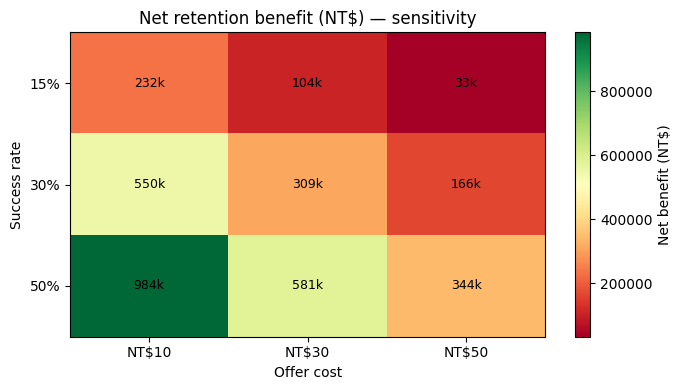

✅ Saved corrected business_layer.parquet, sensitivity_grid.csv, heatmap


In [7]:
# Cell: sensitivity grid + save corrected artifacts
import itertools
grid = pd.DataFrame([allocate(s, o) for s, o in itertools.product([0.15,0.30,0.50],[10,30,50])])
print(grid.to_string(index=False))

biz.to_parquet(f"{PROJECT}/data/processed/business_layer.parquet", index=False)
grid.to_csv(f"{PROJECT}/reports/sensitivity_grid.csv", index=False)

import matplotlib.pyplot as plt
pivot = grid.pivot(index="success_rate", columns="offer_cost", values="net_benefit")
fig, ax = plt.subplots(figsize=(7,4))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([f"NT${c}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels([f"{r:.0%}" for r in pivot.index])
ax.set_xlabel("Offer cost"); ax.set_ylabel("Success rate")
ax.set_title("Net retention benefit (NT$) — sensitivity")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]/1000:.0f}k", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Net benefit (NT$)")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/retention_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved corrected business_layer.parquet, sensitivity_grid.csv, heatmap")

In [8]:
# Cell 0: setup
from google.colab import drive; drive.mount('/content/drive')
!pip install -q lightgbm scikit-learn

import joblib, numpy as np, pandas as pd
PROJECT = "/content/drive/MyDrive/churn-prediction-system"
# Export a realistic default customer + a sample for the Business Impact tab
import pandas as pd, json
biz = pd.read_parquet(f"{PROJECT}/data/processed/business_layer.parquet")
split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_test = split["X_test"]

# A "typical" customer (median-ish, low risk) for the form defaults
typical = X_test.iloc[0].to_dict()
print("DEFAULT CUSTOMER (copy this dict):")
print(json.dumps({k: (round(v,3) if isinstance(v,(int,float)) else v) for k,v in typical.items()}, default=str))

# Save a 500-row sample CSV for the Business Impact tab (features + value columns)
sample = X_test.head(500).copy()
sample.to_csv(f"{PROJECT}/data/processed/sample_customers.csv", index=False)
print("\n✅ Saved sample_customers.csv (download this to churn-api/data/ locally)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEFAULT CUSTOMER (copy this dict):
{"city": 1.0, "bd": NaN, "age_missing": 1.0, "gender": null, "registered_via": 7.0, "txn_count": 1.0, "cancel_count": 1.0, "autorenew_share": 1.0, "last_plan_days": 30.0, "last_actual_paid": 149.0, "last_list_price": 149.0, "last_discount": 0.0, "last_auto_renew": 1.0, "last_is_cancel": 1.0, "payment_method_id": 41.0, "secs_total": 2298.064, "secs_mean": 2298.064, "unq_mean": 20.0, "active_days": 1.0, "plays_100": 5.0, "plays_25": 13.0, "completion_ratio": 0.357, "has_logs": 1, "tenure_days": 99.0, "seq_days_since_last": 6.0, "seq_cancel_last3": 0.0, "seq_price_slope": 0.0, "seq_gap_widening": 0.0, "seq_mean_gap_days": 31.0, "seq_ar_dropped": 0.0}

✅ Saved sample_customers.csv (download this to churn-api/data/ locally)


In [9]:
# Export: risk-segment breakdown (run in business-layer notebook, needs `biz`)
import pandas as pd, numpy as np
# biz has churn_prob, value_at_risk (reload if needed)
# biz = pd.read_parquet(f"{PROJECT}/data/processed/business_layer.parquet")

bins = [0, 0.2, 0.5, 0.8, 0.95, 1.01]
labels = ["Low (0-20%)", "Medium (20-50%)", "High (50-80%)", "Very High (80-95%)", "Critical (95%+)"]
biz["risk_band"] = pd.cut(biz["churn_prob"], bins=bins, labels=labels, include_lowest=True)

# value_at_risk = churn_prob × ltv (recompute if not present)
if "value_at_risk" not in biz.columns:
    biz["value_at_risk"] = biz["churn_prob"] * biz.get("ltv", biz["monthly_value"] * 24)

segments = biz.groupby("risk_band", observed=True).agg(
    customers=("churn_prob", "size"),
    avg_churn_prob=("churn_prob", "mean"),
    total_value_at_risk=("value_at_risk", "sum"),
    avg_monthly_value=("monthly_value", "mean"),
).reset_index()
segments["pct_of_base"] = (100 * segments["customers"] / len(biz)).round(1)
segments = segments.round(2)

segments.to_csv(f"{PROJECT}/reports/risk_segments.csv", index=False)
print(segments.to_string(index=False))
print("\n✅ Saved risk_segments.csv")

         risk_band  customers  avg_churn_prob  total_value_at_risk  avg_monthly_value  pct_of_base
       Low (0-20%)      90043            0.01           3630800.33             128.88         93.6
   Medium (20-50%)       1112            0.31           1239325.04             149.56          1.2
     High (50-80%)        670            0.67           1484107.10             138.68          0.7
Very High (80-95%)        880            0.90           2420350.30             127.76          0.9
   Critical (95%+)       3466            0.99          10252019.98             124.52          3.6

✅ Saved risk_segments.csv


## Summary — Business Layer

Turns calibrated churn probabilities into retention **decisions and dollars**.

**1. Threshold tuning.** Swept cutoffs; F1 peaked at 0.35 (P=0.90, R=0.81, ~5.6% flagged) but stayed flat across 0.25–0.50 — the model ranks cleanly enough that the exact cutoff isn't delicate. The right threshold is a business choice, so the allocator selects by expected dollars, not F1.

**2. Risk-adjusted value.** `monthly_value` = last payment normalised to 30 days. A successful retention offer is modelled as protecting ~3 months of revenue — a deliberately conservative per-offer assumption (not the full lifetime), to avoid over-stating impact.

**3. Retention allocator.** Per customer: `exp_saving = P(churn) × monthly_value × months_protected × success_rate − offer_cost`. Target everyone where this is positive, ranked by expected saving, until the budget is spent.

**4. Results (held-out test set; base case: 30% success, NT\$30 offer, ~3 months protected, NT\$100k budget):**
- **Targeting efficiency (assumption-free headline):** targeted customers churn at **95.2%** vs the **6.3%** population base rate — a **~15× concentration** of real churners. Requires no economic assumptions.
- **Model vs random:** model net **+NT\$309k** vs random **−NT\$75k**. Random spending loses money (most offers reach customers who'd never churn); the model makes money by concentrating spend on genuine high-risk, high-value customers. Robust to the exact economics.
- **Illustrative ROI:** ~308% net return under base-case assumptions.

**5. Sensitivity.** Swept success rate (15–50%) × offer cost (NT\$10–50): profitable across all realistic scenarios. Dollar figures are assumption-dependent (grid + heatmap saved); the targeting-efficiency and model-vs-random results are not.

**Honest framing:** there is no single "correct" ROI — it depends on assumptions only a real A/B test could measure. The model's value is therefore reported primarily via assumption-free targeting efficiency (95% vs 6%) and the model-vs-random comparison, with dollar figures presented as illustrative and bounded by sensitivity analysis.

**Note:** a development iteration revealed a formula error where `1/churn_prob` in the LTV term cancelled the churn signal, making the allocator ignore risk — caught by noticing every `exp_gross` value was identical. Corrected to the per-offer formulation above. Sanity-checking which results are robust vs fragile is itself part of the deliverable.

**Artifacts:** `business_layer.parquet`, `sensitivity_grid.csv`, `retention_sensitivity.png`. The Gradio demo uses identical logic on a 500-row sample for responsiveness.